In [13]:
import pandas as pd
import numpy as np

jahr = '2024'

if jahr == '2025':
    wetter_csv='Wetter/2024_Wetter_Station_020_Mengen_hh24.csv'
else:
    wetter_csv='Wetter/2024_Stunde_077_Hartheim.csv'

wetter=pd.read_csv(wetter_csv,sep=';',decimal=',')
wetter['Datum']=pd.to_datetime(wetter['Tag']+' '+wetter['Stunde'],format='%d.%m.%Y %H:%M',utc=True)
wetter=wetter.set_index('Datum')

In [23]:
Windkraft_je_ms=pd.read_csv('Windanlagen_kw_pro_ms.csv',sep=';')
Windkraft_je_ms['max W/m²']=Windkraft_je_ms.apply(lambda row: pow(min(row['m/s'],15),3)*0.5*1.2, axis= 1)
Windkraft_je_ms['m/s cp']=Windkraft_je_ms['m/s']
Windkraft_je_ms.set_index('m/s',drop=True,inplace=True)
Windkraft_je_ms['rel_V172-7.2']=Windkraft_je_ms['V172-7.2']/Windkraft_je_ms['V172-7.2'].max()
#Windkraft_je_ms.head()

,V162-5.6,V162-6.2,V172-7.2,V172-7.2SO,EK100,1998_600kw,E-126,Kitepower_Hawk,Kitepower_Falcon,SkySails_PN-14,max W/m²,m/s cp,rel_V172-7.2
m/s,,,,,,,,,,,,,
0.0,0,0,0,0,0.0,0,0,-7.0,-4.0,0.0,0.000,0.0,0.0
0.5,0,0,0,0,0.0,0,0,-7.0,-4.0,0.0,0.075,0.5,0.0
1.0,0,0,0,0,0.0,0,0,-6.5,-3.0,0.0,0.600,1.0,0.0
1.5,0,0,0,0,0.0,0,0,-6.0,-2.0,0.0,2.025,1.5,0.0
2.0,0,0,0,0,0.0,0,0,-5.5,-0.5,0.0,4.800,2.0,0.0


In [31]:
faktor=5.7
# Basis Eki
basis=wetter['MAX_WV200max']
# Basis Helgoland
#basis=preis_menge['Wind Helgoland']
#faktor=11.6
fak='{}'.format(faktor)
fak_halbe='{}'.format(faktor/2)
max_wind=500
wetter['Wind '+fak+' m/s']=round(faktor*basis/basis.mean()*2)/2
wetter['Wind '+fak+' m/s']=wetter.apply(lambda row: min(row['Wind '+fak+' m/s'],max_wind),axis= 1)

wetter['max W/m²']=wetter.apply(lambda row: pow(min(row['Wind '+fak+' m/s'],15),3)*0.5*1.2, axis= 1)
wetter['pow H'+fak+' V172']=wetter['Wind '+fak+' m/s'].map(Windkraft_je_ms['rel_V172-7.2'])

wetter['pow H'+fak+' V172']=wetter['pow H'+fak+' V172'].fillna(0)
wetter['z Anzahl']=1

In [101]:
waermebedarf=0.066 # kWh/h*K
# unter 22°C - 
pv_prod=67/5000 # 60kWh pro 5000 Globalstrahlung
pv_prod=pv_prod   # halbierung wegen Wind
wind_pow=6          # 3 kW Anteilige Leistung

In [102]:
wetter['PV']=pv_prod*wetter['SUM_GS200']
#Windkraft_je_ms['max W/m²']=Windkraft_je_ms.apply(lambda row: pow(min(row['m/s'],15),3)*0.5*1.2, axis= 1)
wetter['WP']=wetter.apply(lambda row: max(22-row['AVG_TA200'],0.5)*waermebedarf, axis=1)
wetter['Wind']=wetter['pow H'+fak+' V172']*wind_pow
wetter['Haus']=0.35

In [103]:
r_arr=[]
liste=[0,1,2,3,4,5,6,7,8,9,10,12,15,20,21,22,23,24,25,26,50,75,80,100,500,2599,2600,2700]
liste=[1,15,100]

#for speicherkap in():
for speicherkap in liste:
    speicher_alt=0
    #speicherkap=100
    wetter['Speicher']=0.0
    wetter['VerbrauchSpeicher']=0.0
    
    for cur in range(2):
        a_speicher=[]
        a_verbrauchspeicher=[]
        a_einspeicher=[]
        
        for index, row in wetter.iterrows():
            idx=index
    
            
            
            #rw=wetter.iloc[idx]
            delta=row['PV']+row['Wind']-row['WP']-row['Haus']
    
            speicher_neu=max(min(speicherkap,delta+speicher_alt),0)
    
            verbrauch=max(speicher_alt-speicher_neu,0)
            einspeicher=min(speicher_alt-speicher_neu,0)
            
            a_speicher.append(speicher_neu)
            a_verbrauchspeicher.append(verbrauch)
            a_einspeicher.append(einspeicher)
            speicher_alt=speicher_neu
        wetter['VerbrauchSpeicher']=a_verbrauchspeicher
        wetter['Einspeicher']=a_einspeicher
        wetter['Speicher']=a_speicher

    wetter['Netz +']=wetter.apply(lambda row: max(row['WP']+row['Haus']-row['PV']-row['Wind']-row['VerbrauchSpeicher']-row['Einspeicher'],0), axis=1)
    wetter['Netz -']=wetter.apply(lambda row: min(row['WP']+row['Haus']-row['PV']-row['Wind']-row['VerbrauchSpeicher']-row['Einspeicher'],0), axis=1)
    wetter=wetter.round(6)
    r_arr.append([speicherkap,wetter['VerbrauchSpeicher'].sum()])

In [104]:
df=wetter.reset_index()
df['Monat']=df['Datum'].dt.month
df['Jahr']=df['Datum'].dt.year

agf={'PV':'sum','WP':'sum','Haus':'sum','Wind':'sum','Netz +':'sum','Netz -':'sum','VerbrauchSpeicher':'sum','Einspeicher':'sum','Speicher':["min", "max"]}
cols=['PV','WP','Haus','Wind','Netz +','Netz -','VerbrauchSpeicher','Einspeicher','Speicher']
res=pd.pivot_table(df,index='Monat',values=cols, aggfunc=agf)

#pd.pivot_table(df,index='Monat',values=['PV','WP','Haus','Wind','Netz +','Netz -','VerbrauchSpeicher','Einspeicher','Speicher'], aggfunc={'PV':'sum','Speicher':('max','min')},margins=True,margins_name=jahr)

In [105]:
res

Einspeicher   Haus      Netz +       Netz -          PV Speicher  \
              sum    sum         sum          sum         sum      max   
Monat                                                                    
1     -504.852718  260.4   80.023058  -917.222770   396.44704    100.0   
2     -218.555230  243.6    0.000000 -1754.477974   662.43972    100.0   
3     -327.529578  260.4    0.000000 -1549.760552  1144.19250    100.0   
4     -204.272690  252.0    0.000000 -2479.783220  1503.75470    100.0   
5     -174.230852  260.4    0.000000 -2742.144806  1989.53150    100.0   
6     -148.348668  252.0    0.000000 -2716.157184  2136.25212    100.0   
7     -168.016342  260.4    0.000000 -2537.211782  2411.94640    100.0   
8     -166.284102  260.4    0.000000 -2334.490950  2325.91438    100.0   
9     -221.451424  252.0    0.000000 -1700.565038  1223.90374    100.0   
10    -332.826888  260.4    0.000000  -618.221866   698.17886    100.0   
11    -347.560192  252.0  115.401094  -446.538282   364.53494    100.0   
12    -479.437198  260.4   57.737688  -493.366500   298.39120    100.0   

                 VerbrauchSpeicher        WP         Wind  
             min               sum       sum          sum  
Monat                                                      
1       0.000000        443.901398  909.8034  1671.907392  
2      79.708882        223.084226  608.6256  1939.734858  
3      78.228976        324.965054  629.3298  1297.862376  
4      85.336324        203.716952  517.0506  1745.634858  
5      87.840050        172.419584  333.8478  1348.672374  
6      90.718672        150.983622  186.3114  1015.581510  
7      91.354320        164.755622  136.1646   525.090702  
8      89.883042        167.868902  117.4206   384.812370  
9      81.762928        219.866624  310.5696  1040.815698  
10     59.880464        372.946424  457.7298   598.053270  
11      0.000000        383.074360  755.3568   938.444880  
12      0.000000        465.783114  919.3206  1330.612296

In [94]:
df = pd.DataFrame(r_arr)
v = [0]+[r_arr[i+1][0]-r_arr[i][0] for i in range(len(r_arr)-1)]
r = [0]+[r_arr[i+1][1]-r_arr[i][1] for i in range(len(r_arr)-1)]
df[2]=v
df[3]=r
df[4]=df.apply(lambda row: row[3]/row[2] if (row[2]>0).any() else 0, axis=1)
df=df[(df[0]>0) & (df[0]<200)]

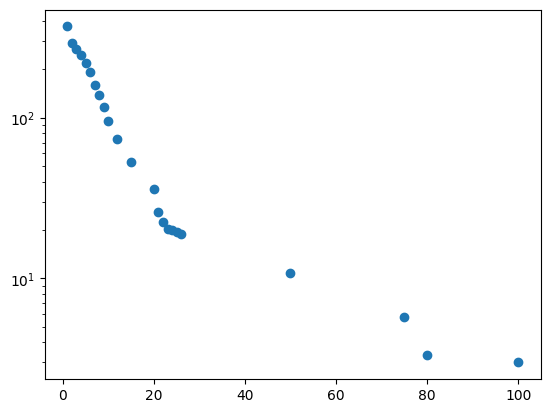

In [96]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
#ax.scatter([r[0] for r in r_arr],[r[1] for r in r_arr])

ax.scatter(df[0],df[4])
#ax.set_xscale('log')
ax.set_yscale('log')
plt.show()

In [97]:
df

,0,1,2,3,4
1,1,370.156490,1,370.156490,370.156490
2,2,662.647856,1,292.491366,292.491366
3,3,928.905379,1,266.257523,266.257523
4,4,1175.089461,1,246.184082,246.184082
5,5,1395.591520,1,220.502059,220.502059
6,6,1589.188701,1,193.597181,193.597181
7,7,1749.655047,1,160.466346,160.466346
8,8,1887.601309,1,137.946262,137.946262
9,9,2004.997541,1,117.396232,117.396232
10,10,2100.288628,1,95.291087,95.291087


In [50]:
speicherkap

100

In [173]:
v=[0]+v

In [175]:
df = pd.DataFrame(t)

In [178]:
df[2]=v

In [90]:
agf={'PV':'sum','WP':'sum','Haus':'sum','Wind':'sum','Netz +':'sum','Netz -':'sum','VerbrauchSpeicher':'sum','Einspeicher':'sum','Speicher':["min", "max"]}
cols=['PV','WP','Haus','Wind','Netz +','Netz -','VerbrauchSpeicher','Einspeicher','Speicher']
pd.pivot_table(df,index='Monat',values=cols, aggfunc=agf)

Einspeicher   Haus Netz +       Netz -          PV     Speicher  \
              sum    sum    sum          sum         sum          max   
Monat                                                                   
1     -482.937923  260.4    0.0     0.000000   198.22352  1990.167876   
2     -729.180146  243.6    0.0     0.000000   331.21986  2152.580373   
3     -728.804859  260.4    0.0     0.000000   572.09625  2473.693005   
4     -499.150782  252.0    0.0  -621.819452   751.87735  2700.000000   
5     -207.923231  260.4    0.0 -1074.548691   994.76575  2700.000000   
6     -173.800298  252.0    0.0 -1138.739029  1068.12606  2700.000000   
7     -183.383091  260.4    0.0 -1068.387468  1205.97320  2700.000000   
8     -182.206894  260.4    0.0  -979.316352  1162.95719  2700.000000   
9     -254.806417  252.0    0.0  -568.775695   611.95187  2700.000000   
10    -274.472541  260.4    0.0   -88.838519   349.08943  2700.000000   
11    -247.694834  252.0    0.0     0.000000   182.26747  2539.253390   
12    -285.654678  260.4    0.0     0.000000   149.19560  2182.607774   

                   VerbrauchSpeicher        WP        Wind  
               min               sum       sum         sum  
Monat                                                       
1      1627.818257        618.964020  909.8034  835.953783  
2      1678.322540        280.318364  608.6256  969.867522  
3      2096.662689        397.507144  629.3298  648.931265  
4      2464.014945        265.325956  517.0506  872.817528  
5      2686.503161        207.617708  333.8478  674.336264  
6      2689.694467        174.933828  186.3114  507.790839  
7      2690.803267        179.816538  136.1646  262.545421  
8      2689.317120        183.980394  117.4206  192.406262  
9      2671.547197        253.791924  310.5696  520.407918  
10     2540.388790        433.324744  457.7298  299.026686  
11     2184.521974        603.561650  755.3568  469.222514  
12     1808.976404        650.873424  919.3206  665.306254

In [86]:
cols

['PV',
 'WP',
 'Haus',
 'Wind',
 'Netz +',
 'Netz -',
 'VerbrauchSpeicher',
 'Einspeicher',
 'Speicher']